# 1.3 Gaussian city

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create a city

2025-06-19 14:06:26,083 - INFO - Initializing city
2025-06-19 14:06:26,086 - INFO - Calculating density profile for 1 cores
2025-06-19 14:06:26,175 - INFO - Running simulation for 5000 steps
2025-06-19 14:06:34,783 - INFO - Simulation completed in 8.61 seconds


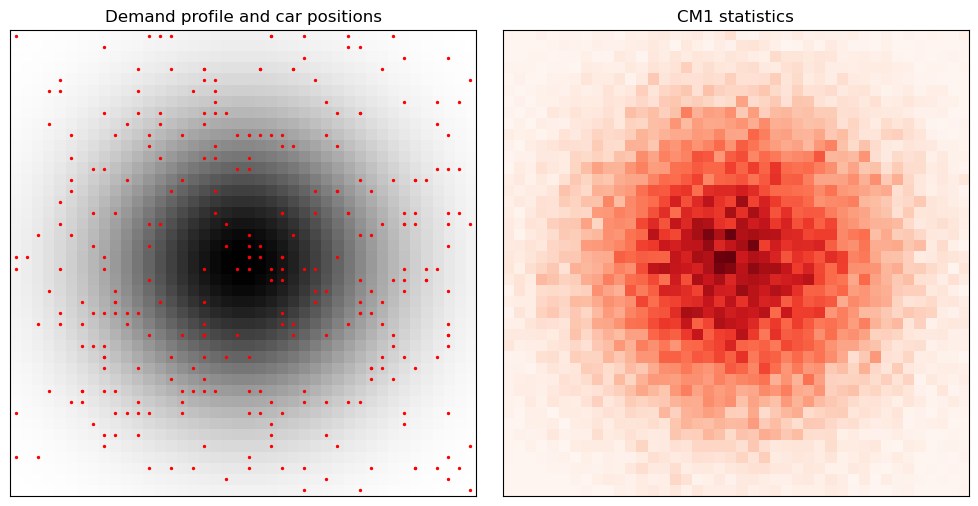

In [2]:
config = {
    "seed": 1,  # Random seed
    "city_width": 21, # km 
    "grid_step": 0.5, 
    "density_sigma": 6, # Gaussian sigma,
    "n_cores": 1, # km
    "n_cars": 300, 
    "settle_down_steps": 50, # Number of steps without stats collection
}

import matplotlib.pyplot as plt
from city_simulator import City

city = City(config)
city.init_cars()
city.simulate(5000)
plt.figure(figsize=(10, 5))
city.visualize()

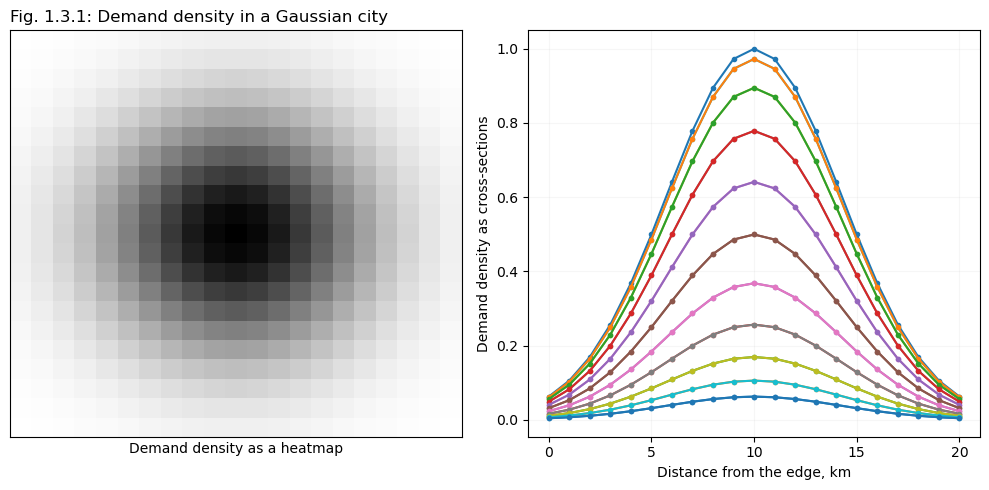

In [6]:
# Population density

# Visualize the city
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(city.grid.T, aspect='auto', interpolation='none',
          extent=[0, city.grid_size, 0, city.grid_size], cmap='gray_r', vmin=0, vmax=1);
plt.xlabel('Demand density as a heatmap')
plt.xticks([], [])
plt.yticks([], [])
plt.title("Fig. 1.3.1: Demand density in a Gaussian city", loc='left')

plt.subplot(122);
plt.plot(np.arange(city.grid_size)*config["grid_step"], city.grid, '.-');
plt.grid(alpha=0.1)
plt.xticks([0, 5, 10, 15, 20])
plt.xlabel('Distance from the edge, km')
plt.ylabel('Demand density as cross-sections')

plt.tight_layout()
plt.savefig("../figures/01simple_03city_01population.svg", dpi=300)

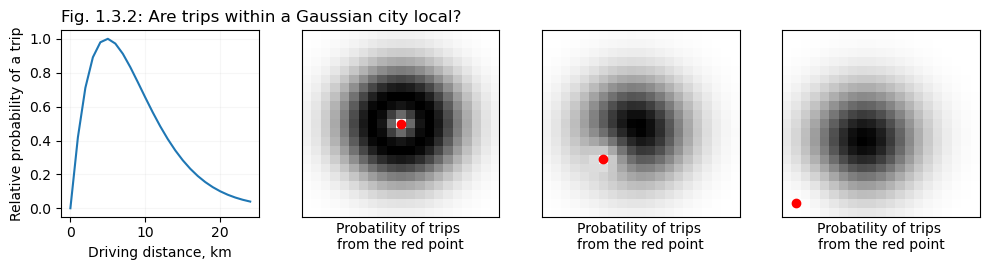

In [8]:
# Spatial mobility curve

n_grid = city.grid_size
density = city.grid

def trip_probability(distance):
    y = distance*np.exp(-(distance**1.2)/8) / 2.11
    return y

x = np.arange(0, 25)
curve = trip_probability(x)

def generate_local_map(i0, j0):
    local_trips = np.zeros(shape=(n_grid, n_grid))
    for i in range(n_grid):
        for j in range(n_grid):
            distance = np.sqrt((i-i0)**2 + (j-j0)**2)*config["grid_step"]        
            local_trips[i, j] = trip_probability(distance)
    local_trips *= density
    local_trips /= local_trips.flatten().max()
    return local_trips

# Figure
plt.figure(figsize=(10, 2.8))
plt.subplot(141)
plt.plot(x, curve)
plt.grid(alpha=0.1)
plt.xlabel('Driving distance, km')
plt.ylabel('Relative probability of a trip')
plt.title("Fig. 1.3.2: Are trips within a Gaussian city local?", loc='left');

plt.subplot(142)
plt.imshow(generate_local_map(10, 10).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(10+0.5, 10+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(143)
plt.imshow(generate_local_map(6, 6).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(6+0.5, 6+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.subplot(144)
plt.imshow(generate_local_map(1, 1).T, aspect='auto', interpolation='none',
          extent=[0, n_grid, 0, n_grid], cmap='gray_r', vmin=0, vmax=1, origin='lower');
plt.plot(1+0.5, 1+0.5, 'ro')
plt.tight_layout()
plt.xticks([], [])
plt.yticks([], [])
plt.xlabel("Probatility of trips \nfrom the red point")

plt.savefig("../figures/01simple_03city_02mobility.svg", dpi=300)

# Fast city simulation